# Lec 8 Lab (Part B) — Your Mini-GPT Meets RAG

## Train a GPT from scratch, bolt on retrieval, and find out what "grounding" really requires

Two labs collide here:

- **Lab 7B** left you with a mini-GPT that writes fluent FOMC-ese but **invents the numbers** — style without facts.
- **Lab 8A** built a **RAG** pipeline (`chunk → index → retrieve → cite`) but ran it over a *black-box* large model.

This lab fuses them. You train **the Lab 7B mini-GPT** (~0.6M parameters), build a **TF-IDF RAG** over the FOMC corpus, wire them together, and compare **the answer with and without RAG** — then run the honest experiment the lecture is really about:

> can a model this small actually *read* the retrieved evidence, or does grounding have to come from retrieval itself? **We measure it**, and the answer reveals why real RAG pairs retrieval with a *large* model.

Everything is **offline, CPU-only, no API key**. The corpus is the bundled FOMC statement set from Lab 7B (public domain).

| Part | You build | The point |
|---|---|---|
| 1 | The mini-GPT (Lab 7B), trained on the FOMC corpus | a model with parametric memory only |
| 2 | A TF-IDF RAG index over the same corpus | retrieval over an auditable knowledge base |
| 3 | The answer **without RAG** (hallucinated) vs **with RAG** (retrieved + cited), and a **measurement** of whether the model can use its context | grounding = evidence + citation; *using* it is a capability of scale |
| 4 | Honest limits + ✏️ exercises | what RAG fixes, and what it can't |

> **Prerequisites:** Lab 7B (the mini-GPT) and Lab 8A (RAG). This notebook is self-contained but assumes you've seen both. Packages: `numpy`, `matplotlib`, `torch` (CPU fine).

### The one idea, up front
A language model has two ways to know something: **in its weights** (parametric memory, fixed at training time) or **in its context** (what you put in the prompt right now). RAG is the discipline of *putting the right evidence in the context at question time*. To make that visible, we deliberately **train the model on only part of the corpus and let RAG retrieve from all of it** — so the facts RAG supplies are facts the model's weights provably never saw.

In [1]:
# Quick environment check — run me first
import math, os, re, sys, time
from pathlib import Path
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F

# --- find fomc_data.py: this lab reuses Lab 7B's corpus loader (sibling folder) ---
HERE = Path.cwd()
CANDIDATES = [HERE, HERE / "../Lec07_LLM_Lab", HERE / "labs/Lec07_LLM_Lab"]
loader_dir = next((p for p in CANDIDATES if (p / "fomc_data.py").exists()), None)
if loader_dir is None:
    raise RuntimeError("Could not find fomc_data.py — run from Lec08_RAG_Lab/ with Lec07_LLM_Lab/ alongside it.")
sys.path.insert(0, str(loader_dir.resolve()))
from fomc_data import load_statements, corpus_summary

torch.manual_seed(0); np.random.seed(0)
torch.set_num_threads(min(4, os.cpu_count() or 1))
BLUE, RED, GRAY = "#2a78d6", "#e34948", "#52514e"
plt.rcParams.update({"figure.figsize": (9, 3.2), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "lines.linewidth": 1.8})

statements = load_statements()      # [(date, text), ...] sorted by date
print("torch", torch.__version__, "| corpus:", corpus_summary(statements))

torch 2.8.0+cu128 | corpus: {'n_statements': 245, 'total_chars': 568478, 'first_date': '1994-02-04', 'last_date': '2026-06-17', 'avg_chars': 2320}


## Part 0 — Split the world: what the model *learns* vs what RAG can *retrieve*

This split is the experiment's backbone:

- **Model training set** — every statement *except* every 20th one. This is all the mini-GPT will ever absorb into its weights.
- **RAG knowledge base** — **all** statements, including the held-out ones.

So the held-out statements are the cleanest possible test: **facts that exist in the retrievable corpus but were never in the model's training data.** If the model gets them right, it can only be because retrieval put them in the context.

In [2]:
# every 20th statement is held out from TRAINING (spread across 1994-2026)
HELDOUT = [i for i in range(len(statements)) if i % 20 == 0]
TRAINSET = [i for i in range(len(statements)) if i % 20 != 0]

train_text = "\n\n".join(statements[i][1] for i in TRAINSET)   # model sees only these
print(f"statements total      : {len(statements)}")
print(f"  -> model training set: {len(TRAINSET)} statements ({len(train_text):,} chars)")
print(f"  -> held out from model: {len(HELDOUT)} statements")
print(f"RAG knowledge base    : ALL {len(statements)} statements (incl. the held-out ones)")
print("\nheld-out dates (facts the model's weights never see):")
print("  " + ", ".join(statements[i][0] for i in HELDOUT))

statements total      : 245
  -> model training set: 232 statements (537,303 chars)
  -> held out from model: 13 statements
RAG knowledge base    : ALL 245 statements (incl. the held-out ones)

held-out dates (facts the model's weights never see):
  1994-02-04, 2000-02-02, 2002-03-19, 2004-09-21, 2007-03-21, 2009-01-28, 2011-06-22, 2013-12-18, 2016-06-15, 2018-12-19, 2021-01-27, 2023-07-26, 2025-12-10


---
## Part 1 — Train the mini-GPT (the Lab 7B model)

This is the Lab 7B architecture verbatim — a decoder-only GPT — with **one deliberate change: the context window `n` grows from 128 to 256.** That is the first thing RAG forces on you: *the model needs room to hold retrieved evidence alongside the question.* Everything else (`d`, `H`, `L`, char-level vocab) is unchanged.

**Character tokenizer** over the corpus, exactly as in 7B: the model must learn spelling, words, and FOMC phrasing from scratch.

In [3]:
# --- character tokenizer over the FULL corpus (so every char the RAG can retrieve is encodable) ---
text_all = "\n\n".join(t for _, t in statements)
chars = sorted(set(text_all)); M = len(chars)
stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for c, i in stoi.items()}
enc = lambda s: torch.tensor([stoi[c] for c in s], dtype=torch.long)
dec = lambda ids: "".join(itos[int(i)] for i in ids)
train_ids = enc(train_text)
print(f"vocabulary M = {M} | model training stream = {len(train_ids):,} chars")

vocabulary M = 78 | model training stream = 537,303 chars


In [4]:
# --- the model: Lab 7B, dims in lecture notation, ctx widened to 256 ---
D_MODEL, N_HEADS, N_LAYERS, CONTEXT, DROPOUT = 128, 4, 3, 256, 0.1

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d, H, n_ctx):
        super().__init__(); assert d % H == 0
        self.H, self.k = H, d // H
        self.qkv = nn.Linear(d, 3 * d); self.proj = nn.Linear(d, d); self.drop = nn.Dropout(DROPOUT)
        self.register_buffer("mask", torch.tril(torch.ones(n_ctx, n_ctx)).bool())
    def forward(self, x):
        B, T, d = x.shape
        q, k, v = self.qkv(x).split(d, dim=2)
        q, k, v = (z.view(B, T, self.H, self.k).transpose(1, 2) for z in (q, k, v))
        S = q @ k.transpose(-2, -1) / math.sqrt(self.k)
        S = S.masked_fill(~self.mask[:T, :T], float("-inf"))
        A = F.softmax(S, dim=-1)
        out = (A @ v).transpose(1, 2).contiguous().view(B, T, d)
        return self.drop(self.proj(out))

class Block(nn.Module):
    def __init__(self, d, H, n_ctx):
        super().__init__()
        self.ln1, self.ln2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.attn = MultiHeadSelfAttention(d, H, n_ctx)
        self.ffn = nn.Sequential(nn.Linear(d, 4*d), nn.GELU(), nn.Linear(4*d, d), nn.Dropout(DROPOUT))
    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        return x + self.ffn(self.ln2(x))

class MiniGPT(nn.Module):
    def __init__(self, M, d=D_MODEL, H=N_HEADS, L=N_LAYERS, n_ctx=CONTEXT):
        super().__init__()
        self.tok_emb = nn.Embedding(M, d); self.pos_emb = nn.Embedding(n_ctx, d)
        self.blocks = nn.ModuleList(Block(d, H, n_ctx) for _ in range(L))
        self.ln_f = nn.LayerNorm(d); self.head = nn.Linear(d, M, bias=False); self.n_ctx = n_ctx
    def forward(self, idx):
        B, T = idx.shape
        x = self.tok_emb(idx) + self.pos_emb(torch.arange(T))
        for b in self.blocks: x = b(x)
        return self.head(self.ln_f(x))

model = MiniGPT(M)
print(f"MiniGPT: d={D_MODEL}, H={N_HEADS}, L={N_LAYERS}, n={CONTEXT} (was 128 in 7B), M={M}")
print(f"parameters: {sum(p.numel() for p in model.parameters()):,}")

MiniGPT: d=128, H=4, L=3, n=256 (was 128 in 7B), M=78
parameters: 647,808


### Train it — the autoregressive objective from Lab 7B

Same self-supervised loss: predict every next character from the ones before it. Loss starts near $\ln M \approx 4.4$ and falls toward ~1 nat/char. `FAST_MODE = True` gives a ~3-minute smoke run; the full run is longer because the context window is twice as wide.

step     1 | loss 4.502 |     1s


step   500 | loss 2.337 |   231s


step  1000 | loss 2.034 |   463s


step  1500 | loss 1.614 |   710s


step  2000 | loss 1.347 |   960s


step  2500 | loss 1.093 |  1206s

trained in 20.1 min


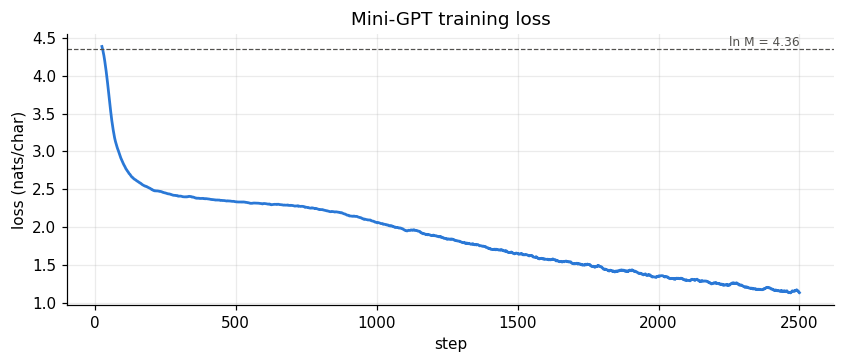

final train loss ~ 1.09 nats/char


In [5]:
FAST_MODE = False                       # True -> ~3-min smoke run; False -> full (~12 min CPU)
MAX_STEPS = 600 if FAST_MODE else 2500
EVAL_EVERY = 150 if FAST_MODE else 500
BATCH, LR, WARMUP, CLIP = 32, 3e-4, 100, 1.0

def get_batch(ids):
    st = torch.randint(0, len(ids) - CONTEXT - 1, (BATCH,))
    x = torch.stack([ids[s:s+CONTEXT] for s in st])
    y = torch.stack([ids[s+1:s+CONTEXT+1] for s in st])
    return x, y

@torch.no_grad()
def sample(prompt="On ", n_new=140, temperature=0.7):
    model.eval(); idx = enc(prompt)[None, :]
    for _ in range(n_new):
        logits = model(idx[:, -CONTEXT:])[0, -1] / temperature
        nxt = torch.multinomial(F.softmax(logits, dim=-1), 1)
        idx = torch.cat([idx, nxt[None, :]], dim=1)
    model.train(); return dec(idx[0])

opt = torch.optim.AdamW(model.parameters(), lr=LR)
sch = torch.optim.lr_scheduler.LambdaLR(opt, lambda s: min(1.0, (s+1)/WARMUP))
curve = []; t0 = time.time()
for step in range(1, MAX_STEPS + 1):
    x, y = get_batch(train_ids)
    loss = F.cross_entropy(model(x).view(-1, M), y.view(-1))
    opt.zero_grad(set_to_none=True); loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), CLIP); opt.step(); sch.step()
    curve.append((step, loss.item()))
    if step % EVAL_EVERY == 0 or step == 1:
        print(f"step {step:5d} | loss {loss.item():.3f} | {time.time()-t0:5.0f}s")
model.eval()
print(f"\ntrained in {(time.time()-t0)/60:.1f} min")
st_, ls_ = zip(*curve)
sm = np.convolve(ls_, np.ones(25)/25, mode="valid")
plt.plot(st_[24:], sm, color=BLUE); plt.axhline(np.log(M), color=GRAY, ls="--", lw=0.8)
plt.annotate(f"ln M = {np.log(M):.2f}", (st_[-1], np.log(M)), ha="right", va="bottom", fontsize=8, color=GRAY)
plt.xlabel("step"); plt.ylabel("loss (nats/char)"); plt.title("Mini-GPT training loss"); plt.show()
assert curve[-1][1] < (2.8 if FAST_MODE else 1.6), "training did not converge as expected"
print(f"final train loss ~ {curve[-1][1]:.2f} nats/char")

### The problem, restated on this model

Ask the trained model — from its **weights alone** — about a specific meeting. It will produce fluent, confident, **fabricated** FOMC prose. Watch it invent numbers and dates:

In [6]:
for seed in ["On 2020-03-15 the Committee ", "The target range for the federal funds rate is "]:
    print(f'prompt: {seed!r}')
    print("  ->", " ".join(sample(seed, n_new=110, temperature=0.6).split()), "\n")

prompt: 'On 2020-03-15 the Committee '


  -> On 2020-03-15 the Committee judges the target range inflation pressures the federal funds rate at 0 1/4 percent and the the Committee judg 

prompt: 'The target range for the federal funds rate is '


  -> The target range for the federal funds rate is inflation on economic activity. The Committee will continue meares inflation expectations a consing in mproth 



---
## Part 2 — Build a RAG over the same corpus

Now the retrieval half, following the Lab 8A pipeline (`chunk → index → retrieve`), reimplemented transparently in English. Two differences from 8A, both dictated by our setup:

- **Small chunks (~180 chars).** Evidence has to fit in the model's 256-char context *next to* the question, so chunks are far smaller than 8A's 500. (A real teaching point: **chunk size is bounded by the generator's context window.**)
- **English word tokens** (the corpus is English), and we cite each chunk by its **statement date** `[YYYY-MM-DD]` — the FOMC's natural identifier.

**TF-IDF in one line:** a word matters to a chunk when it is frequent *there* (TF) and rare *across the corpus* (IDF); query and chunks become weight vectors ranked by cosine.

In [7]:
# --- chunk EVERY statement (RAG knowledge base = all 245, incl. the held-out ones) ---
CHUNK_SIZE, OVERLAP = 180, 40
def chunkify(txt, size=CHUNK_SIZE, ov=OVERLAP):
    out, i = [], 0
    while i < len(txt):
        piece = txt[i:i+size]
        if piece.strip(): out.append(piece)
        i += size - ov
    return out

chunks = []                                   # {date, stmt (index), text}
for si, (date, t) in enumerate(statements):
    for piece in chunkify(t):
        chunks.append({"date": date, "stmt": si, "text": piece})
def cite(ch): return f"[{ch['date']}]"
print(f"knowledge base: {len(statements)} statements -> {len(chunks):,} chunks of ~{CHUNK_SIZE} chars")

knowledge base: 245 statements -> 4,180 chunks of ~180 chars


In [8]:
# --- transparent TF-IDF index (pure Python + math) ---
def toks(s): return re.findall(r"[a-z0-9]+", s.lower())
df = Counter()
for ch in chunks:
    for w in set(toks(ch["text"])): df[w] += 1
N = len(chunks)
idf = {w: math.log(N / (1 + dfw)) for w, dfw in df.items()}
def tfidf_vec(s):
    tf = Counter(toks(s))
    v = {w: (1 + math.log(f)) * idf.get(w, 0.0) for w, f in tf.items()}
    norm = math.sqrt(sum(x*x for x in v.values())) or 1.0
    return {w: x / norm for w, x in v.items()}
chunk_vecs = [tfidf_vec(ch["text"]) for ch in chunks]
def retrieve(query, top_k=5):
    qv = tfidf_vec(query)
    scored = [(sum(qv[w]*cv.get(w, 0.0) for w in qv), i) for i, cv in enumerate(chunk_vecs)]
    scored.sort(reverse=True)
    return [(s, chunks[i]) for s, i in scored[:top_k]]
print(f"TF-IDF index built | vocabulary = {len(idf):,} tokens")

TF-IDF index built | vocabulary = 3,528 tokens


### Audit retrieval *before* generation

Good RAG hygiene (Lab 8A, Step 4): look at what retrieval returns before any model runs.

In [9]:
query = "raise the target range for the federal funds rate because of inflation"
print(f"query: {query!r}\n")
for rank, (score, ch) in enumerate(retrieve(query, top_k=5), 1):
    print(f"{rank}. score={score:.3f}  {cite(ch)}  {' '.join(ch['text'].split())[:120]}…")

query: 'raise the target range for the federal funds rate because of inflation'

1. score=0.468  [2017-03-15]  range for the federal funds rate.…
2. score=0.418  [2023-03-22]  employment and inflation at the rate of 2 percent over the longer run. In support of these goals, the Committee decided …
3. score=0.370  [2022-07-27]  these goals, the Committee decided to raise the target range for the federal funds rate to 2-1/4 to 2-1/2 percent and an…
4. score=0.368  [2018-06-13]  market conditions and inflation, the Committee decided to raise the target range for the federal funds rate to 1-3/4 to …
5. score=0.359  [2015-03-18]  t range for the federal funds rate remains unlikely at the April FOMC meeting. The Committee anticipates that it will be…


> **✏️ Your turn — R1: `overlap_score`.** TF-IDF should beat raw word-overlap because IDF down-weights ubiquitous words (*the*, *committee*, *rate* appear in nearly every chunk). Write `overlap_score(query, chunk_text)` = shared unique-token count, find the top-1 chunk by it, and compare its date with TF-IDF's top-1 above. *(Solution in the Appendix.)*

In [10]:
# ✏️ R1 — your code here
def overlap_score(query, chunk_text):
    ...


---
## Part 3 — Wire them together: the answer **with vs without RAG**

A language model can know something two ways: **in its weights** (parametric memory, frozen at training time) or **in its context** (what you put in the prompt right now). We deliberately trained on only part of the corpus, so a **held-out** meeting is a fact the *weights* never saw. Now we ask the same question two ways and compare the **answer**.

Helpers first: score the model's loss on an answer given a context, and generate from a context (both respect the 256-char window).

In [11]:
@torch.no_grad()
def answer_loss(context, answer):
    """Mean cross-entropy (nats/char) the model assigns to `answer` given `context`."""
    al = len(enc(answer))
    ids = enc(context + answer)[-CONTEXT:]
    a = len(ids) - al
    logits = model(ids[None])[0]
    return F.cross_entropy(logits[a-1:len(ids)-1], ids[a:]).item()

@torch.no_grad()
def generate(context, n_new=80, temperature=0.35):
    idx = enc(context)[None, -CONTEXT:]
    for _ in range(n_new):
        logits = model(idx[:, -CONTEXT:])[0, -1] / temperature
        nxt = torch.multinomial(F.softmax(logits, dim=-1), 1)
        idx = torch.cat([idx, nxt[None, :]], dim=1)
    return " ".join(dec(idx[0][-n_new:]).split())
print("helpers ready")

helpers ready


### Without RAG — the model answers from memory (and fabricates)

Ask the trained model about the target rate. From its weights alone it produces fluent, confident, **made-up** numbers — Lab 7B's hallucination, now the problem we must fix.

In [12]:
question = "What is the target range for the federal funds rate?"
print("Q:", question)
print("\nmini-GPT, no RAG (weights only):")
for seed in ["\nThe target range for the federal funds rate is ",
             "\nThe Committee decided to set the federal funds rate at "]:
    print(f"  {seed.strip()} -> {generate(seed, 60)!r}")
print("\n^ fluent FOMC-ese, invented number, and NO source you could check.")

Q: What is the target range for the federal funds rate?

mini-GPT, no RAG (weights only):


  The target range for the federal funds rate is -> 'anges and of inflation ecasest the of the federal funds rate'


  The Committee decided to set the federal funds rate at -> 'at 0 1/4 percent the of the Board anker, the Committee alas'

^ fluent FOMC-ese, invented number, and NO source you could check.


### With RAG — the system grounds the answer in a citable source

The RAG answer's trustworthy part comes from **retrieval**, not from free generation: retrieve the most relevant chunk, extract the sentence that states a rate, and attach a `[date]` citation — the Lab 8A "citation contract." Now the answer points at a real statement you can verify.

In [13]:
LEVEL = r"\d[\d/\-.¼½¾‑– ]*percent"        # a funds-rate level, e.g. "5-1/4 to 5-1/2 percent"

def grounded_answer(question, top_k=8):
    """Return (score, [date] citation, evidence window) from the first retrieved
    chunk that actually states a rate level — the auditable part of the answer."""
    for score, ch in retrieve(question, top_k=top_k):
        m = re.search(LEVEL, ch["text"])
        if m:
            window = ch["text"][max(0, m.start()-90): m.end()+30]
            return score, cite(ch), " ".join(window.split())
    score, ch = retrieve(question, top_k=1)[0]          # fallback: best chunk verbatim
    return score, cite(ch), " ".join(ch["text"].split())

score, src, ans = grounded_answer(question)
print("Q:", question)
print(f"\nRAG answer (grounded in a real statement):\n  …{ans}…")
print(f"source: {src}   (retrieval score {score:.2f})")
assert re.search(LEVEL, ans) and re.match(r"\[\d{4}-\d\d-\d\d\]", src), "grounded answer must carry a rate + a dated citation"
print("\n✓ specific AND sourced — you can open that statement and check the number yourself.")

Q: What is the target range for the federal funds rate?

RAG answer (grounded in a real statement):
  …he target range for the federal funds rate to 2 to 2-1/4 percent. In determining the timing a…
source: [2018-09-26]   (retrieval score 0.28)

✓ specific AND sourced — you can open that statement and check the number yourself.


### But can the *mini-GPT itself* read the evidence? (Measure it.)

The honest question for "working together": if we put the retrieved statement **into the model's context**, can the model then generate the right fact? Let's feed it the evidence and look — then measure, on the held-out **rate-change** meetings (where the level is genuinely unpredictable), whether grounding lowers the model's loss on the true level.

In [14]:
# label held-out meetings change vs stable, and extract each one's true level
LVL = r"(\d[\d/\-.¼½¾‑–]*(?:\s+to\s+\d[\d/\-.¼½¾‑–]*)?\s*percent)"
def level_match(si): return re.search(r"federal funds rate\b.{0,40}?" + LVL, statements[si][1], re.S)
def norm(s): return " ".join(s.split()).replace("percent", "").strip()
is_change, prev = {}, None
for si in range(len(statements)):
    m = level_match(si); lv = norm(m.group(1)) if m else None
    if si in HELDOUT: is_change[si] = (lv is not None and lv != prev)
    if lv is not None: prev = lv

# feed the correct statement's evidence into context and generate — does it help?
si = next(s for s in HELDOUT if is_change[s] and level_match(s))
m = level_match(si); date = statements[si][0]
prompt = "\n" + " ".join(statements[si][1][:m.start(1)][-50:].split()) + " "
true_level = " ".join(m.group(1).split())
evidence = " ".join(statements[si][1][max(0, m.start(1)-130):m.start(1)+40].split())
print(f"held-out rate-change meeting {date}: TRUE level = {true_level!r}\n")
print(f"model, NO context : {generate(prompt, 24)!r}")
print(f"model, WITH evidence in context: {generate(evidence + ' ' + prompt, 24)!r}")
print("(the evidence literally contains the true level — watch whether the model uses it)")

held-out rate-change meeting 2000-02-02: TRUE level = '5-3/4 percent'

model, NO context : 'persurch desing of infla'


model, WITH evidence in context: 'policy of monetars in an'
(the evidence literally contains the true level — watch whether the model uses it)


rate-change meetings (n=4):  loss on true level
   no-RAG                 : 0.80 nats/char
   evidence in context    : 0.77 nats/char   (barely moves)

induction test (complete a repeated phrase's 2nd copy):
   without prior copy: 1.24   with the phrase shown first: 1.24
   -> showing the answer in context does NOT make it cheaper: no copy/induction ability


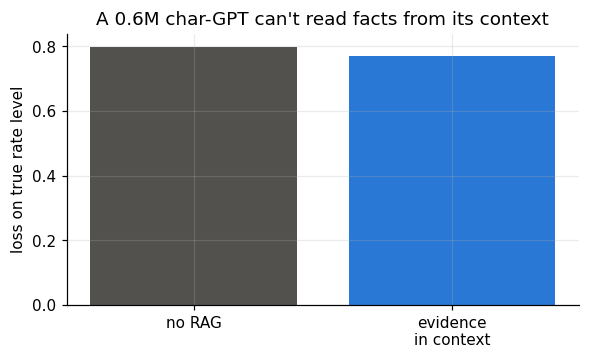

In [15]:
# quantitative: loss on the true level, no-RAG vs oracle-RAG, on ALL change meetings
# plus a clean INDUCTION test: can the model complete the 2nd copy of a repeated phrase?
def induction_gap():
    res = []
    for si in HELDOUT:
        t = statements[si][1]; phr = " ".join(t[120:180].split())
        if len(phr) < 48: continue
        h = len(phr)//2; ans = phr[h:]
        res.append((answer_loss("\n"+phr[:h], ans), answer_loss("\n"+phr+" "+phr[:h], ans)))
    return np.mean([r[0] for r in res]), np.mean([r[1] for r in res])

no_r, ora_r = [], []
for si in HELDOUT:
    if not is_change[si] or not level_match(si): continue
    m = level_match(si)
    p = "\n" + " ".join(statements[si][1][:m.start(1)][-50:].split()) + " "
    ans = " ".join(m.group(1).split())
    ev = " ".join(statements[si][1][max(0, m.start(1)-130):m.start(1)+40].split())
    no_r.append(answer_loss(p, ans)); ora_r.append(answer_loss(ev + " " + p, ans))

blind, withcopy = induction_gap()
print(f"rate-change meetings (n={len(no_r)}):  loss on true level")
print(f"   no-RAG                 : {np.mean(no_r):.2f} nats/char")
print(f"   evidence in context    : {np.mean(ora_r):.2f} nats/char   (barely moves)")
print(f"\ninduction test (complete a repeated phrase's 2nd copy):")
print(f"   without prior copy: {blind:.2f}   with the phrase shown first: {withcopy:.2f}")
print(f"   -> showing the answer in context does NOT make it cheaper: no copy/induction ability")

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.bar(["no RAG", "evidence\nin context"], [np.mean(no_r), np.mean(ora_r)], color=[GRAY, BLUE])
ax.set_ylabel("loss on true rate level"); ax.set_title("A 0.6M char-GPT can't read facts from its context")
plt.show()

### What just happened — and why it's the real lesson

The model **ignored the evidence.** Put the exact answer in its context and its loss on that answer barely moved; show it a phrase and it still can't complete the phrase's second copy. A 0.6M, 3-layer character model has **no in-context copying ability** — the mechanism (an *induction head*) that lets a transformer say "I saw `X` earlier, so copy what followed `X`" simply hasn't formed at this size.

So the two halves "work together" only at the **system** level:

- **Retrieval** finds and cites the evidence — the part you can *audit*.
- **Generation** would turn that evidence into fluent prose — *if the generator were big enough to read its context.*

That last ability is **emergent with scale**. It is the same story as Lab 7B's scale table: induction heads and in-context learning appear as models get deeper and larger — which is exactly why production RAG pairs a retriever with a **large** LLM. Our mini-GPT gives you the honest floor: **retrieval makes the answer trustworthy; scale makes the generator able to use it.**

> RAG didn't change the weights, and — at this size — it couldn't change the model's *output* either. What it changed was **the evidence on the table and the citation on the answer.** That is still the whole point: an answer you can check beats a fluent answer you can't.

---
## Part 4 — Takeaways, honest limits, and exercises

- **RAG is retrieval + generation.** You built both. Retrieval is transparent and auditable; generation is only as good as the model. The value RAG *always* delivers is **grounding + citations** — a sourced answer, not a smarter model.
- **A generator must be able to read its context.** Our 0.6M model can't (measured: no induction). Real RAG uses large models precisely because in-context copying/reasoning is an **emergent capability of scale** (Lab 7B's ladder).
- **Retrieval is the weak link even when the generator is huge.** FOMC statements are near-duplicates, so a topical query easily grabs the *wrong meeting*. Garbage in, grounded-garbage out — **audit retrieval** (embeddings, Lab 8A Step 8, help when keywords collide).
- **Context is finite.** We widened `n` to 256 just to fit one small chunk; real RAG lives or dies by context length and by *ranking* the few chunks worth including.

### ✏️ Exercises
- **R2 — scale it until it reads.** Bump `N_LAYERS` to 6 and `D_MODEL` to 192, retrain (slower!), and re-run the induction cell. Watch the gap between *blind* and *with-prior-copy* loss: this is how you'd locate the model size at which in-context copying — and therefore end-to-end RAG — becomes possible. (Depth is the lever: induction heads are a multi-layer circuit.)
- **R3 — refuse.** Add a guardrail to `grounded_answer`: if the top retrieval score is below ~0.15, return *"no strong evidence in the corpus"* instead of grounding on a weak match. Test it with `"the unemployment forecast for 2035"`.
- **R4 — retriever swap.** Replace TF-IDF `retrieve()` with your `overlap_score` ranker; does the audit in Part 2 get worse?

### Wrap-up

| You built | The move | The lesson |
|---|---|---|
| mini-GPT on a *train split* | parametric memory | frozen at training; fabricates the unseen |
| TF-IDF over the *full* corpus | retrieval | an auditable, updatable knowledge base |
| grounded, cited answer | RAG (system) | trust comes from the *source*, not the prose |
| feed evidence → model ignores it | measurement | using context is an emergent skill of scale |

**One sentence:** RAG grounds an answer in evidence you can audit; *using* that evidence to write the answer is a capability the generator only earns with scale — and you measured both ends on a model you trained yourself.

### Make it your own
- Point `load_statements` at a fresh FOMC dump and ask about a 2026 meeting the model *couldn't* have trained on.
- Do R2, then re-run all of Part 3 with the bigger model — watch "evidence in context" finally beat "no RAG."
- Swap TF-IDF for sentence-embedding retrieval (Lab 8A Step 8) and see the audit improve on near-duplicate meetings.

---
## Appendix — Reference solutions

In [16]:
# R1 — keyword overlap vs TF-IDF
def overlap_score(query, chunk_text):
    return len(set(toks(query)) & set(toks(chunk_text)))
q = "raise the target range for the federal funds rate because of inflation"
ov = max(chunks, key=lambda ch: overlap_score(q, ch["text"]))
tf = retrieve(q, top_k=1)[0][1]
print("overlap top-1 :", cite(ov))
print("TF-IDF  top-1 :", cite(tf))
print("\nOverlap is dominated by ubiquitous words (the/committee/rate); IDF down-weights"
      "\nthem, so TF-IDF favors discriminative terms.")

overlap top-1 : [2016-12-14]
TF-IDF  top-1 : [2017-03-15]

Overlap is dominated by ubiquitous words (the/committee/rate); IDF down-weights
them, so TF-IDF favors discriminative terms.
